# Counter-UAS Glider — Scratch Notebook v2

Clean self-contained implementation. No OOP. Everything in one file.

**Scenario:**
- Fixed-wing UAS infiltrates a defended corridor from z_start to z_goal
- Phase 1: powered climb at fixed climb rate h_dot
- Phase 2: unpowered glide divided into N_SEG altitude segments, each with its own gamma_i
- One sensor suite collocated at (Z_D, 0) on the ground
- Attacker minimizes J_A = alpha_1*J_PD + alpha_2*T_norm

**Nonholonomic constraint enforced:**
Once gamma is chosen, trim airspeed v(gamma) is determined by the glide polar.
The attacker cannot choose v and gamma independently.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
print('Imports OK')

Imports OK


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


---
## Section 1 — Constants
Change these freely. Everything else derives from them.

In [ ]:
# ── Corridor ─────────────────────────────────────────────────────────────────
Z_START = 0.0
Z_GOAL  = 10000.0   # m

# ── Sensor placement (heuristic) ─────────────────────────────────────────────
# Place sensor at 30% of corridor so attacker must pass over it
# while still having altitude to glide the remaining 70%
Z_D = Z_GOAL*0.7   # m  — change this to explore different placements

# ── Airframe ─────────────────────────────────────────────────────────────────
C_D0      = 0.025
K_INDUCED = 0.045
W         = 150.0    # N
RHO       = 1.225    # kg/m^3
S_WING    = 0.8      # m^2

# ── Powered phase ─────────────────────────────────────────────────────────────
V_CLIMB   = 15.0     # m/s  horizontal speed during climb
H_DOT_MAX = 10.0      # m/s  max climb rate

# ── Glide phase ───────────────────────────────────────────────────────────────
GAMMA_MIN_DEG = -45.0   # deg  steepest glide
GAMMA_MAX_DEG = -2.0    # deg  shallowest glide
GAMMA_MIN     = np.radians(GAMMA_MIN_DEG)
GAMMA_MAX     = np.radians(GAMMA_MAX_DEG)
N_SEG         = 20      # number of altitude segments

# ── Simulation ────────────────────────────────────────────────────────────────
DT = 0.5   # s  timestep

# ── Cost weights ──────────────────────────────────────────────────────────────
ALPHA_1 = 0.9   # weight on J_PD
ALPHA_2 = 0.1   # weight on T_norm

# ── Sensor model parameters ───────────────────────────────────────────────────
N_ACOUSTIC        = 6.0    # propeller dipole exponent
SIGMA_PSI_DEG     = 30.0   # RCS Gaussian spread (deg)
FOV_HALF_DEG      = 45.0   # camera FOV half-angle (deg)
CAM_ELEVATION_DEG = 45.0   # camera boresight elevation (deg)

# Sensor kappas — will be calibrated in Section 4
# These are just initial placeholders
KAPPA_AC   = 1.0
KAPPA_DOPP = 1.0
KAPPA_RCS  = 1.0
KAPPA_CAM  = 1.0

print('Constants set.')
print(f'  Corridor: z=[{Z_START:.0f}, {Z_GOAL:.0f}] m')
print(f'  Sensor:   z_d={Z_D:.0f} m  ({100*Z_D/Z_GOAL:.0f}% of corridor)')
print(f'  Segments: N={N_SEG}')

Constants set.
  Corridor: z=[0, 10000] m
  Sensor:   z_d=7000 m  (70% of corridor)
  Segments: N=10


---
## Section 2 — Glide Polar

Parabolic drag polar enforces the nonholonomic constraint.
Once gamma is chosen, trim airspeed v(gamma) is determined.

In [3]:
# ── Best-glide quantities ─────────────────────────────────────────────────────
CL_STAR    = np.sqrt(C_D0 / K_INDUCED)
CD_STAR    = C_D0 + K_INDUCED * CL_STAR**2   # = 2*C_D0
LD_MAX     = CL_STAR / CD_STAR
GAMMA_STAR = -np.arctan(1.0 / LD_MAX)         # best glide angle (negative)
V_STAR     = np.sqrt(2*W*np.cos(abs(GAMMA_STAR)) / (RHO*S_WING*CL_STAR))

print(f'Glide polar:')
print(f'  (L/D)_max  = {LD_MAX:.2f}')
print(f'  gamma*     = {np.degrees(GAMMA_STAR):.2f} deg')
print(f'  v*         = {V_STAR:.2f} m/s')
print(f'  CD* = 2*C_D0? {np.isclose(CD_STAR, 2*C_D0)} ✓')


def glide_speed(gamma):
    """
    Trim airspeed at glide angle gamma.
    Nonholonomic constraint: v and gamma coupled through polar.
    Stable branch: steeper gamma -> lower CL -> higher v.
    """
    gamma = float(np.clip(gamma, GAMMA_MIN, GAMMA_MAX))
    tan_g = np.tan(abs(gamma))
    disc  = tan_g**2 - 4.0 * K_INDUCED * C_D0
    if disc < 0:
        CL = CL_STAR   # shallower than gamma* not possible unpowered
    else:
        CL = max((tan_g - np.sqrt(disc)) / (2.0 * K_INDUCED), 0.01)
    return np.sqrt(2*W*np.cos(abs(gamma)) / (RHO*S_WING*CL))


# Sanity: glide_speed(gamma*) should equal v*
assert abs(glide_speed(GAMMA_STAR) - V_STAR) < 1.0, 'Polar sanity check failed'
print(f'  Sanity check passed: glide_speed(gamma*) = {glide_speed(GAMMA_STAR):.2f} = v* ✓')

# T_max for normalizing flight time
T_MAX = (Z_GOAL - Z_START) / V_STAR
print(f'  T_max = {T_MAX:.1f} s')

Glide polar:
  (L/D)_max  = 14.91
  gamma*     = -3.84 deg
  v*         = 20.24 m/s
  CD* = 2*C_D0? True ✓
  Sanity check passed: glide_speed(gamma*) = 20.24 = v* ✓
  T_max = 494.0 s


---
## Section 3 — Trajectory Simulation

Key design decisions:
1. h_sw is a FREE variable — optimizer chooses it
2. z_sw is DERIVED from h_sw and h_dot (not free)
3. Glide divided into N_SEG altitude segments
4. Dynamic gamma ceiling enforces vehicle reaches ground at z_goal
5. NO auto-correction of infeasible parameters — caller must ensure feasibility

In [4]:
# def simulate(h_dot, h_sw, gammas_seg,
#              z_start=Z_START, z_goal=Z_GOAL, v_climb=V_CLIMB, dt=DT):
#     """
#     Simulate full hybrid trajectory.

#     Parameters
#     ----------
#     h_dot      : float  climb rate during Phase 1 (m/s)
#     h_sw       : float  engine cutoff altitude (m)
#     gammas_seg : array of N_SEG glide angles (rad), one per altitude band

#     Returns
#     -------
#     dict: t, z, h, v, gamma, phase arrays + h_sw, z_sw, delta scalars
#     """
#     h_dot = float(np.clip(h_dot, 0.1, H_DOT_MAX))
#     h_sw  = float(h_sw)
#     N     = len(gammas_seg)

#     # Derived switch point — NOT a free variable
#     t_climb = h_sw / h_dot
#     z_sw    = z_start + v_climb * t_climb
#     delta   = z_sw + h_sw * LD_MAX - z_goal   # range budget

#     # Caller must ensure feasibility — no silent correction here
#     if delta < 0:
#         raise ValueError(f'Infeasible: delta={delta:.1f} m')
#     if z_sw >= z_goal:
#         raise ValueError(f'z_sw={z_sw:.1f} >= z_goal={z_goal}')

#     gamma_climb = np.arctan2(h_dot, v_climb)

#     t_arr, z_arr, h_arr, v_arr, g_arr, ph_arr = [], [], [], [], [], []

#     # ── Phase 1: powered climb ────────────────────────────────────────────
#     t, z, h = 0.0, z_start, 0.0
#     while h < h_sw - 1e-3 and z < z_goal:
#         t_arr.append(t); z_arr.append(z); h_arr.append(h)
#         v_arr.append(v_climb); g_arr.append(gamma_climb); ph_arr.append(1)
#         z += v_climb * dt
#         h += h_dot   * dt
#         t += dt

#     # Exact switch point
#     t_arr.append(t_climb); z_arr.append(z_sw); h_arr.append(h_sw)
#     v_arr.append(v_climb);  g_arr.append(gamma_climb); ph_arr.append(1)

#     # ── Phase 2: segmented glide ──────────────────────────────────────────
#     # Altitude segment boundaries: evenly spaced from h_sw down to 0
#     bounds    = np.linspace(h_sw, 0.0, N + 1)
#     t         = t_climb
#     z         = z_sw
#     h         = h_sw
#     delta_rem = delta
#     gamma     = GAMMA_STAR   # initial value before first step
#     v         = glide_speed(gamma)

#     while h > 1e-3 and z < z_goal:

#         # Which altitude segment are we in?
#         seg_idx = N - 1
#         for i in range(N):
#             if h >= bounds[i + 1]:
#                 seg_idx = i
#                 break

#         # Desired gamma from optimizer for this segment
#         gamma_desired = float(np.clip(gammas_seg[seg_idx], GAMMA_MIN, GAMMA_MAX))

#         # Dynamic ceiling: gamma must be steep enough to reach ground at z_goal
#         # Required: tan|gamma_req| = h / (z_goal - z)
#         z_rem = z_goal - z
#         if z_rem > 1.0 and h > 0.1:
#             gamma_req = -np.arctan(h / z_rem)
#             # gamma_req is more negative (steeper) than needed
#             # ceiling = whichever is steeper of GAMMA_MAX and gamma_req
#             gamma_ceiling = min(GAMMA_MAX, gamma_req)   # min = more negative = steeper
#         else:
#             gamma_ceiling = GAMMA_MIN

#         # Budget enforcement: force gamma* if budget exhausted
#         if delta_rem <= 0.0:
#             delta_rem     = 0.0
#             gamma_desired = GAMMA_STAR
#             gamma_ceiling = min(GAMMA_MAX, -np.arctan(h / max(z_rem, 1.0)))

#         # Final gamma: clip desired to [GAMMA_MIN, gamma_ceiling]
#         gamma = float(np.clip(gamma_desired, GAMMA_MIN, gamma_ceiling))

#         # Nonholonomic constraint: v determined by gamma
#         v         = glide_speed(gamma)
#         z_dot     = v * np.cos(abs(gamma))
#         h_dot_g   = v * np.sin(gamma)   # negative

#         t_arr.append(t); z_arr.append(z); h_arr.append(h)
#         v_arr.append(v); g_arr.append(gamma); ph_arr.append(2)

#         # Range budget decrement
#         cot_star  = LD_MAX
#         tan_g     = np.tan(abs(gamma))
#         cot_gamma = 1.0 / tan_g if tan_g > 1e-6 else 1e6
#         decrement = (cot_star - cot_gamma) * abs(h_dot_g) * dt
#         delta_rem -= decrement

#         z += z_dot  * dt
#         h += h_dot_g * dt
#         h  = max(h, 0.0)   # never go underground
#         t += dt

#     # Final point — clamp to ground and z_goal
#     t_arr.append(t)
#     z_arr.append(min(z, z_goal))
#     h_arr.append(0.0)   # attacker reached ground
#     v_arr.append(v); g_arr.append(gamma); ph_arr.append(2)

#     return {
#         't':     np.array(t_arr),
#         'z':     np.array(z_arr),
#         'h':     np.array(h_arr),
#         'v':     np.array(v_arr),
#         'gamma': np.array(g_arr),
#         'phase': np.array(ph_arr),
#         'h_sw':  h_sw,
#         'z_sw':  z_sw,
#         'delta': delta,
#     }

def simulate(h_dot, z_sw, gammas_seg,
                z_start=Z_START, z_goal=Z_GOAL,
                v_climb=V_CLIMB, dt=DT):
    """
    Simulate trajectory.
    Decision variables: h_dot and z_sw (NOT h_sw).
    h_sw is DERIVED from h_dot and z_sw.
    This eliminates the feasibility coupling problem.
    """
    h_dot = float(np.clip(h_dot, 0.1, H_DOT_MAX))
    z_sw  = float(np.clip(z_sw, z_start + 100, z_goal - 100))

    # h_sw derived — not a free variable
    t_climb = (z_sw - z_start) / v_climb
    h_sw    = h_dot * t_climb

    # Delta: always check
    delta = z_sw + h_sw * LD_MAX - z_goal
    # No correction — caller enforces via bounds

    gamma_climb = np.arctan2(h_dot, v_climb)
    N           = len(gammas_seg)
    bounds_seg  = np.linspace(h_sw, 0.0, N + 1)

    t_arr, z_arr, h_arr = [], [], []
    v_arr, g_arr, ph_arr = [], [], []

    # Phase 1: powered climb
    t, z, h = 0.0, z_start, 0.0
    while h < h_sw - 1e-3 and z < z_sw - 1e-3:
        t_arr.append(t); z_arr.append(z); h_arr.append(h)
        v_arr.append(v_climb); g_arr.append(gamma_climb); ph_arr.append(1)
        z += v_climb * dt
        h += h_dot   * dt
        t += dt

    # Exact switch point
    t_arr.append(t_climb); z_arr.append(z_sw); h_arr.append(h_sw)
    v_arr.append(v_climb);  g_arr.append(gamma_climb); ph_arr.append(1)

    # Phase 2: segmented glide
    t         = t_climb
    z         = z_sw
    h         = h_sw
    delta_rem = delta
    gamma     = GAMMA_STAR
    v         = glide_speed(gamma)

    while h > 1e-3 and z < z_goal:
        # Segment index
        seg_idx = N - 1
        for i in range(N):
            if h >= bounds_seg[i + 1]:
                seg_idx = i
                break

        gamma_desired = float(np.clip(gammas_seg[seg_idx], GAMMA_MIN, GAMMA_MAX))

        # Dynamic ceiling: must reach ground by z_goal
        z_rem = z_goal - z
        if z_rem > 1.0 and h > 0.1:
            gamma_ceiling = min(GAMMA_MAX, -np.arctan(h / z_rem))
        else:
            gamma_ceiling = GAMMA_MIN

        # Budget enforcement
        if delta_rem <= 0.0:
            delta_rem     = 0.0
            gamma_desired = GAMMA_STAR

        gamma = float(np.clip(gamma_desired, GAMMA_MIN, gamma_ceiling))
        v     = glide_speed(gamma)
        z_dot   = v * np.cos(abs(gamma))
        h_dot_g = v * np.sin(gamma)   # negative

        t_arr.append(t); z_arr.append(z); h_arr.append(h)
        v_arr.append(v); g_arr.append(gamma); ph_arr.append(2)

        # Budget
        tan_g     = np.tan(abs(gamma))
        cot_gamma = 1.0 / tan_g if tan_g > 1e-6 else 1e6
        delta_rem -= (LD_MAX - cot_gamma) * abs(h_dot_g) * dt

        z += z_dot   * dt
        h  = max(h + h_dot_g * dt, 0.0)
        t += dt

    # Final point
    t_arr.append(t); z_arr.append(min(z, z_goal)); h_arr.append(0.0)
    v_arr.append(v); g_arr.append(gamma); ph_arr.append(2)

    return {
        't':     np.array(t_arr),
        'z':     np.array(z_arr),
        'h':     np.array(h_arr),
        'v':     np.array(v_arr),
        'gamma': np.array(g_arr),
        'phase': np.array(ph_arr),
        'h_sw':  h_sw,
        'z_sw':  z_sw,
        'delta': delta,
    }


# Quick test with reasonable parameters
# Engine cuts before sensor, meaningful altitude
_h_dot_test  = 4.0
_h_sw_test   = 400.0
_gammas_test = np.full(N_SEG, GAMMA_STAR)
_traj_test   = simulate(_h_dot_test, _h_sw_test, _gammas_test)

print(f'Test trajectory:')
print(f'  z_sw     = {_traj_test["z_sw"]:.1f} m  (must be < Z_D={Z_D:.0f})')
print(f'  h_sw     = {_traj_test["h_sw"]:.1f} m')
print(f'  delta    = {_traj_test["delta"]:.1f} m  (must be > 0)')
print(f'  T        = {_traj_test["t"][-1]:.1f} s')
print(f'  final h  = {_traj_test["h"][-1]:.2f} m  (should be ~0)')
print(f'  final z  = {_traj_test["z"][-1]:.1f} m  (should be ~Z_GOAL={Z_GOAL:.0f})')
print(f'  n_points = {len(_traj_test["t"])}')

Test trajectory:
  z_sw     = 400.0 m  (must be < Z_D=7000)
  h_sw     = 106.7 m
  delta    = -8009.9 m  (must be > 0)
  T        = 105.7 s
  final h  = 0.00 m  (should be ~0)
  final z  = 1995.6 m  (should be ~Z_GOAL=10000)
  n_points = 214


---
## Section 4 — Sensor Models and Calibration

In [5]:
# ── Camera boresight (precomputed once) ───────────────────────────────────────
_elev = np.radians(CAM_ELEVATION_DEG)
B_HAT = np.array([-np.cos(_elev), np.sin(_elev)])


# ── Geometry helpers ─────────────────────────────────────────────────────────
def sensor_range(z, h, z_d=Z_D):
    return float(np.sqrt((z_d - z)**2 + h**2))

def los_angle(z, h, z_d=Z_D):
    dz = abs(z_d - z)
    return float(np.pi/2 if dz < 1e-6 else np.arctan2(h, dz))

def radial_velocity(z, h, v, gamma, z_d=Z_D):
    return float(v * np.cos(los_angle(z, h, z_d) - abs(gamma)))

def aspect_angle_deg(z, h, gamma, z_d=Z_D):
    psi = abs((np.pi/2.0 + gamma) - los_angle(z, h, z_d))
    return float(np.degrees(psi))

def boresight_angle(z, h, z_d=Z_D):
    u = np.array([z - z_d, h])
    n = np.linalg.norm(u)
    if n < 1e-6: return 0.0
    return float(np.arccos(np.clip(np.dot(B_HAT, u/n), -1.0, 1.0)))


# ── Sensor hazard rate functions ──────────────────────────────────────────────
def lam_acoustic(z, h, v, gamma, phase, z_d=Z_D, kappa=None):
    """Active Phase 1 only. lambda = kappa * v^n / r^2"""
    if phase != 1: return 0.0
    r = sensor_range(z, h, z_d)
    if r < 1.0: return 0.0
    if kappa is None: kappa = KAPPA_AC
    return kappa * (v ** N_ACOUSTIC) / (r ** 2)

def lam_doppler(z, h, v, gamma, phase, z_d=Z_D, kappa=None):
    """Both phases. lambda = kappa * v_r^2 / r^4"""
    r = sensor_range(z, h, z_d)
    if r < 1.0: return 0.0
    if kappa is None: kappa = KAPPA_DOPP
    vr = radial_velocity(z, h, v, gamma, z_d)
    return kappa * (vr ** 2) / (r ** 4)

def lam_rcs(z, h, v, gamma, phase, z_d=Z_D, kappa=None):
    """Both phases. lambda = kappa * sigma(psi) / r^4"""
    r = sensor_range(z, h, z_d)
    if r < 1.0: return 0.0
    if kappa is None: kappa = KAPPA_RCS
    sig_rad = np.radians(SIGMA_PSI_DEG)
    psi_rad = np.radians(aspect_angle_deg(z, h, gamma, z_d))
    sigma   = np.exp(-((psi_rad - np.pi/2)**2) / (2*sig_rad**2))
    return kappa * sigma / (r ** 4)

def lam_camera(z, h, v, gamma, phase, z_d=Z_D, kappa=None):
    """Both phases. lambda = kappa * cos^2(phi) / r^2 if in FOV"""
    r = sensor_range(z, h, z_d)
    if r < 1.0: return 0.0
    if kappa is None: kappa = KAPPA_CAM
    phi = boresight_angle(z, h, z_d)
    if phi > np.radians(FOV_HALF_DEG): return 0.0
    return kappa * (np.cos(phi)**2) / (r**2)

def lam_total(z, h, v, gamma, phase, z_d=Z_D):
    return (lam_acoustic(z, h, v, gamma, phase, z_d) +
            lam_doppler( z, h, v, gamma, phase, z_d) +
            lam_rcs(     z, h, v, gamma, phase, z_d) +
            lam_camera(  z, h, v, gamma, phase, z_d))


# ── Calibration ───────────────────────────────────────────────────────────────
# Target: each sensor contributes integral = TARGET_PER_SENSOR
# Total integral = 4 * TARGET -> J_PD = 1 - exp(-4*TARGET)
# Choose TARGET so J_PD is in [0.4, 0.7] on reference trajectory
TARGET_PER_SENSOR = 0.05   # total ~0.6 -> J_PD ~0.45

# Reference trajectory for calibration
# Use h_dot that puts z_sw well before Z_D
_h_dot_cal = H_DOT_MAX
_h_sw_cal  = (_traj_test['h_sw'])   # reuse feasible h_sw from test
_g_cal     = np.full(N_SEG, GAMMA_STAR)
_traj_cal  = simulate(_h_dot_cal, _h_sw_cal, _g_cal)

print(f'Calibration trajectory: z_sw={_traj_cal["z_sw"]:.0f}m, h_sw={_traj_cal["h_sw"]:.0f}m')

def integrate_traj(traj, sensor_fn, kappa=1.0, z_d=Z_D):
    """Trapezoidal integration of sensor_fn over trajectory."""
    n   = len(traj['t'])
    lam = np.array([sensor_fn(traj['z'][i], traj['h'][i], traj['v'][i],
                              traj['gamma'][i], traj['phase'][i], z_d, kappa)
                    for i in range(n)])
    dt  = np.diff(traj['t'])
    return float(np.sum(0.5*(lam[:-1]+lam[1:])*dt))

# Raw integrals with kappa=1
I_ac   = integrate_traj(_traj_cal, lam_acoustic, kappa=1.0)
I_dopp = integrate_traj(_traj_cal, lam_doppler,  kappa=1.0)
I_rcs  = integrate_traj(_traj_cal, lam_rcs,      kappa=1.0)
I_cam  = integrate_traj(_traj_cal, lam_camera,   kappa=1.0)

print(f'Raw integrals (kappa=1): ac={I_ac:.3e}, dopp={I_dopp:.3e}, rcs={I_rcs:.3e}, cam={I_cam:.3e}')

# Scale kappas
KAPPA_AC   = TARGET_PER_SENSOR / I_ac   if I_ac   > 0 else 1e-6
KAPPA_DOPP = TARGET_PER_SENSOR / I_dopp if I_dopp > 0 else 1e-6
KAPPA_RCS  = TARGET_PER_SENSOR / I_rcs  if I_rcs  > 0 else 1e-6
KAPPA_CAM  = TARGET_PER_SENSOR / I_cam  if I_cam  > 0 else 1e-6

print(f'Calibrated kappas:')
print(f'  KAPPA_AC   = {KAPPA_AC:.4e}')
print(f'  KAPPA_DOPP = {KAPPA_DOPP:.4e}')
print(f'  KAPPA_RCS  = {KAPPA_RCS:.4e}')
print(f'  KAPPA_CAM  = {KAPPA_CAM:.4e}')

# Verify J_PD on calibration trajectory
I_total_cal = TARGET_PER_SENSOR * 4
J_PD_cal    = 1.0 - np.exp(-I_total_cal)
print(f'\nVerification: J_PD on calibration traj = {J_PD_cal:.4f}')

Calibration trajectory: z_sw=107m, h_sw=71m
Raw integrals (kappa=1): ac=1.679e+00, dopp=1.386e-11, rcs=3.411e-14, cam=7.340e-07
Calibrated kappas:
  KAPPA_AC   = 2.9787e-02
  KAPPA_DOPP = 3.6082e+09
  KAPPA_RCS  = 1.4658e+12
  KAPPA_CAM  = 6.8120e+04

Verification: J_PD on calibration traj = 0.1813


---
## Section 5 — Cost Functions

In [6]:
def compute_jpd(traj, z_d=Z_D):
    """
    Compute cumulative J_PD and running J_PD array.
    J_PD = 1 - exp(-integral(sum_k lambda_k dt))
    Poisson fusion: Zabarankin et al. (2006) NRL.
    """
    n   = len(traj['t'])
    lam = np.array([
        lam_total(traj['z'][i], traj['h'][i], traj['v'][i],
                  traj['gamma'][i], traj['phase'][i], z_d)
        for i in range(n)
    ])
    dt      = np.diff(traj['t'])
    cumint  = np.concatenate([[0], np.cumsum(0.5*(lam[:-1]+lam[1:])*dt)])
    jpd_run = 1.0 - np.exp(-cumint)
    return float(jpd_run[-1]), jpd_run, lam


def compute_ja(traj, z_d=Z_D):
    """Compute J_A = alpha_1*J_PD + alpha_2*T_norm."""
    J_PD, jpd_run, lam = compute_jpd(traj, z_d)
    T      = float(traj['t'][-1] - traj['t'][0])
    T_norm = float(np.clip(T / T_MAX, 0.0, 1.0))
    J_A    = ALPHA_1 * J_PD + ALPHA_2 * T_norm
    return J_A, J_PD, T_norm, jpd_run, lam


# Quick check
J_A_t, J_PD_t, T_norm_t, _, _ = compute_ja(_traj_cal)
print(f'Calibration trajectory: J_PD={J_PD_t:.4f}, T_norm={T_norm_t:.4f}, J_A={J_A_t:.4f}')

Calibration trajectory: J_PD=0.1813, T_norm=0.1207, J_A=0.1752


---
## Section 6 — Attacker Optimization

Decision variables: (h_dot, h_sw, gamma_1, ..., gamma_N)
Total: 2 + N_SEG variables.

Constraints enforced BEFORE simulation:
1. delta >= 0 (can reach z_goal)
2. z_sw < Z_D (engine cuts before sensor)
3. h_sw >= H_SW_MIN (meaningful altitude)

In [7]:
# ── Optimizer bounds ──────────────────────────────────────────────────────────
H_DOT_MIN = 0.5
H_DOT_MAX_OPT = H_DOT_MAX

# H_SW_MIN: meaningful altitude — must be large enough to have a real glide
# Rule: after engine cut, attacker should have at least enough altitude
# to glide past the sensor. Minimum = sensor overflight altitude.
# With z_sw_max = Z_D - 100 and best glide from there:
# h_sw_min * LD_MAX >= Z_GOAL - (Z_D - 100) -> h_sw_min >= ...
# H_SW_MIN = max(200.0, (Z_GOAL - Z_D) / LD_MAX * 0.5)

# H_SW_MAX: largest h_sw such that Delta >= 0 for worst-case h_dot = H_DOT_MIN
# h_sw*(LD_MAX + V_CLIMB/H_DOT_MIN) <= Z_GOAL - Z_START
# H_SW_MAX = (Z_GOAL - Z_START) / (LD_MAX + V_CLIMB / H_DOT_MIN) * 0.95

# H_SW_MAX first
H_SW_MAX = (Z_GOAL - Z_START) / (LD_MAX + V_CLIMB / H_DOT_MIN) * 0.95

# H_SW_MIN: meaningful altitude, but must be less than H_SW_MAX
H_SW_MIN = min(
    max(50.0, (Z_GOAL - Z_D) / LD_MAX * 0.3),  # geometry-based minimum
    H_SW_MAX * 0.5                               # never exceed half of H_SW_MAX
)

print(f'  h_sw:  [{H_SW_MIN:.1f}, {H_SW_MAX:.1f}] m')
assert H_SW_MIN < H_SW_MAX, f'H_SW_MIN={H_SW_MIN:.1f} >= H_SW_MAX={H_SW_MAX:.1f}'

print(f'Optimizer bounds:')
print(f'  h_dot: [{H_DOT_MIN}, {H_DOT_MAX_OPT}] m/s')
print(f'  h_sw:  [{H_SW_MIN:.1f}, {H_SW_MAX:.1f}] m')
print(f'  gamma: [{GAMMA_MIN_DEG}, {GAMMA_MAX_DEG}] deg')

# Verify H_SW_MIN puts z_sw before Z_D
_t_min = H_SW_MIN / H_DOT_MAX_OPT
_z_sw_at_min = Z_START + V_CLIMB * _t_min
print(f'\n  z_sw at (H_SW_MIN, H_DOT_MAX) = {_z_sw_at_min:.1f} m  (must be < Z_D={Z_D:.0f})')
if _z_sw_at_min >= Z_D:
    print('  WARNING: z_sw >= Z_D at minimum h_sw. Reduce H_SW_MIN or increase Z_D.')
else:
    print('  OK ✓')


# def run_optimizer(z_d=Z_D, n_seg=N_SEG, method='differential_evolution',
#                   verbose=True):
#     """
#     Find attacker's optimal trajectory for fixed sensor placement z_d.

#     Parameters
#     ----------
#     method : 'differential_evolution' or 'nelder-mead'
#     """

#     def objective(x):
#         h_dot  = float(np.clip(x[0], H_DOT_MIN, H_DOT_MAX_OPT))
#         h_sw   = float(np.clip(x[1], H_SW_MIN,  H_SW_MAX))
#         gammas = np.clip(x[2:], GAMMA_MIN, GAMMA_MAX)

#         # Check feasibility BEFORE simulating — return penalty if infeasible
#         t_climb = h_sw / h_dot
#         z_sw    = Z_START + V_CLIMB * t_climb
#         delta   = z_sw + h_sw * LD_MAX - Z_GOAL

#         if delta < 0:
#             return 1.0   # infeasible: cannot reach z_goal
#         if z_sw >= z_d:
#             return 1.0   # infeasible: engine cuts after sensor

#         try:
#             traj = simulate(h_dot, h_sw, gammas)
#             J_A, _, _, _, _ = compute_ja(traj, z_d)
#             return float(J_A)
#         except Exception:
#             return 1.0

#     if method == 'differential_evolution':
#         bounds = ([(H_DOT_MIN, H_DOT_MAX_OPT),
#                    (H_SW_MIN,  H_SW_MAX)] +
#                   [(GAMMA_MIN, GAMMA_MAX)] * n_seg)
#         if verbose:
#             print(f'Running Differential Evolution ({2+n_seg} variables)...')
#         res = differential_evolution(
#             objective, bounds,
#             maxiter=300, popsize=12, tol=1e-6,
#             seed=42, polish=False,
#             disp=verbose
#         )
#     else:
#         gamma_mid = (GAMMA_MIN + GAMMA_MAX) / 2.0
#         x0 = np.array([
#             (H_DOT_MIN + H_DOT_MAX_OPT) / 2.0,
#             (H_SW_MIN  + H_SW_MAX)  / 2.0,
#             *([gamma_mid] * n_seg)
#         ])
#         if verbose:
#             print(f'Running Nelder-Mead ({2+n_seg} variables)...')
#         res = minimize(objective, x0, method='nelder-mead',
#                        options={'maxiter': 10000, 'xatol': 1e-4,
#                                 'fatol': 1e-6, 'disp': verbose})

#     # Extract optimal values
#     # h_dot_opt  = float(np.clip(res.x[0], H_DOT_MIN, H_DOT_MAX_OPT))
#     # h_sw_opt   = float(np.clip(res.x[1], H_SW_MIN,  H_SW_MAX))
#     # gammas_opt = np.clip(res.x[2:], GAMMA_MIN, GAMMA_MAX)

#     # traj_opt = simulate(h_dot_opt, h_sw_opt, gammas_opt)
#     h_dot_opt  = float(np.clip(res.x[0], H_DOT_MIN, H_DOT_MAX_OPT))
#     h_sw_opt   = float(np.clip(res.x[1], H_SW_MIN,  H_SW_MAX))
#     gammas_opt = np.clip(res.x[2:], GAMMA_MIN, GAMMA_MAX)

#     # Recheck feasibility after clipping — clipping can break it
#     t_climb_opt = h_sw_opt / h_dot_opt
#     z_sw_opt    = Z_START + V_CLIMB * t_climb_opt
#     delta_opt   = z_sw_opt + h_sw_opt * LD_MAX - Z_GOAL

#     if delta_opt < 0:
#         # h_sw too small for this h_dot — increase h_sw to minimum feasible
#         denom     = LD_MAX + V_CLIMB / h_dot_opt
#         h_sw_opt  = float((Z_GOAL - Z_START) / denom * 1.05)
#         h_sw_opt  = float(np.clip(h_sw_opt, H_SW_MIN, H_SW_MAX))

#     if z_sw_opt >= Z_D:
#         # z_sw past sensor — increase h_dot so climb is faster
#         # z_sw = V_CLIMB * h_sw / h_dot < Z_D
#         # h_dot > V_CLIMB * h_sw / Z_D
#         h_dot_opt = float(np.clip(V_CLIMB * h_sw_opt / (Z_D - 1.0),
#                                 H_DOT_MIN, H_DOT_MAX_OPT))

#     traj_opt = simulate(h_dot_opt, h_sw_opt, gammas_opt)
#     J_A_opt, J_PD_opt, T_norm_opt, jpd_run, lam = compute_ja(traj_opt, z_d)

#     if verbose:
#         print(f'\nOptimal attacker decisions:')
#         print(f'  h_dot  = {h_dot_opt:.3f} m/s')
#         print(f'  h_sw   = {h_sw_opt:.1f} m    (H_SW_MIN={H_SW_MIN:.0f})')
#         print(f'  z_sw   = {traj_opt["z_sw"]:.1f} m  (Z_D={z_d:.0f})')
#         print(f'  gammas = {np.degrees(gammas_opt).round(1)} deg')
#         print(f'\nCosts:')
#         print(f'  J_PD   = {J_PD_opt:.4f}')
#         print(f'  T_norm = {T_norm_opt:.4f}')
#         print(f'  J_A    = {J_A_opt:.4f}')
#         print(f'\nOptimizer: success={res.success}, n_evals={res.nfev}')

#     return {
#         'h_dot':   h_dot_opt,
#         'h_sw':    h_sw_opt,
#         'z_sw':    traj_opt['z_sw'],
#         'gammas':  gammas_opt,
#         'J_A':     J_A_opt,
#         'J_PD':    J_PD_opt,
#         'T_norm':  T_norm_opt,
#         'traj':    traj_opt,
#         'jpd_run': jpd_run,
#         'lam':     lam,
#         'success': res.success,
#         'n_evals': res.nfev,
#     }


def run_optimizer(z_d=Z_D, n_seg=N_SEG, verbose=True):
    """
    Optimizer with (h_dot, z_sw, gamma_1..N) as decision variables.
    Feasibility is guaranteed by bounds — no runtime checks needed.
    """
    # z_sw must be before sensor AND delta must be >= 0
    # delta = z_sw + h_sw*LD - z_goal = z_sw + h_dot*(z_sw/v_climb)*LD - z_goal
    # For delta >= 0:
    # z_sw*(1 + h_dot*LD/v_climb) >= z_goal
    # z_sw >= z_goal / (1 + h_dot*LD/v_climb)
    # Worst case h_dot = H_DOT_MAX:
    z_sw_min = max(
        Z_GOAL / (1.0 + H_DOT_MAX * LD_MAX / V_CLIMB) * 1.05,
        Z_START + 100.0
    )
    z_sw_max = z_d - 100.0   # must cut before sensor

    print(f'Bounds: z_sw=[{z_sw_min:.0f}, {z_sw_max:.0f}] m')

    if z_sw_min >= z_sw_max:
        print(f'ERROR: z_sw bounds inverted. '
              f'z_d={z_d:.0f} is too close to start. '
              f'Increase Z_D or decrease Z_GOAL.')
        return None

    bounds = ([(0.1, H_DOT_MAX),
               (z_sw_min, z_sw_max)] +
              [(GAMMA_MIN, GAMMA_MAX)] * n_seg)

    def objective(x):
        h_dot  = float(x[0])
        z_sw   = float(x[1])
        gammas = x[2:]
        try:
            traj = simulate(h_dot, z_sw, gammas)
            if traj['delta'] < 0:
                return 1.0
            J_A, _, _, _, _ = compute_ja(traj, z_d)
            return float(J_A)
        except Exception:
            return 1.0

    if verbose:
        print(f'Running Differential Evolution ({2+n_seg} variables)...')

    res = differential_evolution(
        objective, bounds,
        maxiter=300, popsize=12, tol=1e-6,
        seed=42, polish=False, disp=verbose
    )

    h_dot_opt  = float(np.clip(res.x[0], 0.1, H_DOT_MAX))
    z_sw_opt   = float(np.clip(res.x[1], z_sw_min, z_sw_max))
    gammas_opt = np.clip(res.x[2:], GAMMA_MIN, GAMMA_MAX)

    traj_opt = simulate(h_dot_opt, z_sw_opt, gammas_opt)
    J_A_opt, J_PD_opt, T_norm_opt, jpd_run, lam = compute_ja(traj_opt, z_d)

    return {
        'h_dot':   h_dot_opt,
        'z_sw':    z_sw_opt,
        'h_sw':    traj_opt['h_sw'],
        'gammas':  gammas_opt,
        'J_A':     J_A_opt,
        'J_PD':    J_PD_opt,
        'T_norm':  T_norm_opt,
        'traj':    traj_opt,
        'jpd_run': jpd_run,
        'lam':     lam,
        'success': res.success,
        'n_evals': res.nfev,
    }


# Run optimizer — use differential_evolution for better global search
# result = run_optimizer(z_d=Z_D, n_seg=N_SEG,
#                        method='differential_evolution', verbose=True)
result = run_optimizer(z_d=Z_D, n_seg=N_SEG, verbose=True)

  h_sw:  [60.4, 211.5] m
Optimizer bounds:
  h_dot: [0.5, 10.0] m/s
  h_sw:  [60.4, 211.5] m
  gamma: [-45.0, -2.0] deg

  z_sw at (H_SW_MIN, H_DOT_MAX) = 90.6 m  (must be < Z_D=7000)
  OK ✓
Bounds: z_sw=[960, 6900] m
Running Differential Evolution (12 variables)...
differential_evolution step 1: f(x)= 0.970733
differential_evolution step 2: f(x)= 0.970195
differential_evolution step 3: f(x)= 0.969098
differential_evolution step 4: f(x)= 0.967789
differential_evolution step 5: f(x)= 0.967095
differential_evolution step 6: f(x)= 0.966004
differential_evolution step 7: f(x)= 0.965076
differential_evolution step 8: f(x)= 0.965076
differential_evolution step 9: f(x)= 0.965076
differential_evolution step 10: f(x)= 0.964977
differential_evolution step 11: f(x)= 0.964977
differential_evolution step 12: f(x)= 0.964616
differential_evolution step 13: f(x)= 0.964616
differential_evolution step 14: f(x)= 0.964616
differential_evolution step 15: f(x)= 0.964166
differential_evolution step 16: f(x)=

---
## Section 7 — Diagnostic: Three-Way Contradiction Check

Compare J_A at three extreme gamma profiles.
If optimal < both extremes, interior optimum exists = contradiction active.

In [8]:
h_dot_r = result['h_dot']
h_sw_r  = result['h_sw']

# Shallow: all segments at gamma_max
traj_shallow = simulate(h_dot_r, h_sw_r, np.full(N_SEG, GAMMA_MAX))
J_A_sh, J_PD_sh, _, _, _ = compute_ja(traj_shallow, Z_D)

# Steep: all segments at gamma_min
traj_steep = simulate(h_dot_r, h_sw_r, np.full(N_SEG, GAMMA_MIN))
J_A_st, J_PD_st, _, _, _ = compute_ja(traj_steep, Z_D)

# Best glide: all segments at gamma*
traj_star = simulate(h_dot_r, h_sw_r, np.full(N_SEG, GAMMA_STAR))
J_A_star, J_PD_star, _, _, _ = compute_ja(traj_star, Z_D)

print('Three-way contradiction diagnostic:')
print(f'  Shallow (gamma_max={GAMMA_MAX_DEG:.1f} deg): J_A={J_A_sh:.4f}, J_PD={J_PD_sh:.4f}')
print(f'  Best glide (gamma*={np.degrees(GAMMA_STAR):.1f} deg):  J_A={J_A_star:.4f}, J_PD={J_PD_star:.4f}')
print(f'  Steep  (gamma_min={GAMMA_MIN_DEG:.1f} deg): J_A={J_A_st:.4f}, J_PD={J_PD_st:.4f}')
print(f'  Optimal:                         J_A={result["J_A"]:.4f}, J_PD={result["J_PD"]:.4f}')
print(f'  J_A range (shallow vs steep):    {abs(J_A_sh - J_A_st):.4f}')

if result['J_A'] < min(J_A_sh, J_A_st) - 1e-4:
    print('\n  ✓ Interior optimum found — contradiction ACTIVE')
elif result['J_A'] <= min(J_A_sh, J_A_st) + 1e-4:
    print('\n  ~ Optimal matches an extreme — contradiction may be weak')
else:
    print('\n  ✗ Optimal worse than extreme — optimizer did not converge')

print(f'\nGamma profile:')
print(f'  Values: {np.degrees(result["gammas"]).round(2)} deg')
print(f'  Std dev: {np.degrees(result["gammas"].std()):.4f} deg')
if result['gammas'].std() > np.radians(1.0):
    print('  ✓ Gammas vary across segments — curved trajectory')
else:
    print('  ~ Gammas nearly constant — effectively straight line')

Three-way contradiction diagnostic:
  Shallow (gamma_max=-2.0 deg): J_A=0.9688, J_PD=1.0000
  Best glide (gamma*=-3.8 deg):  J_A=0.9688, J_PD=1.0000
  Steep  (gamma_min=-45.0 deg): J_A=0.9988, J_PD=1.0000
  Optimal:                         J_A=0.9628, J_PD=1.0000
  J_A range (shallow vs steep):    0.0300

  ✓ Interior optimum found — contradiction ACTIVE

Gamma profile:
  Values: [ -2.43  -2.91  -8.12  -3.69  -4.76  -7.99  -3.08  -6.67  -2.52 -45.  ] deg
  Std dev: 12.2713 deg
  ✓ Gammas vary across segments — curved trajectory


---
## Section 8 — Plots

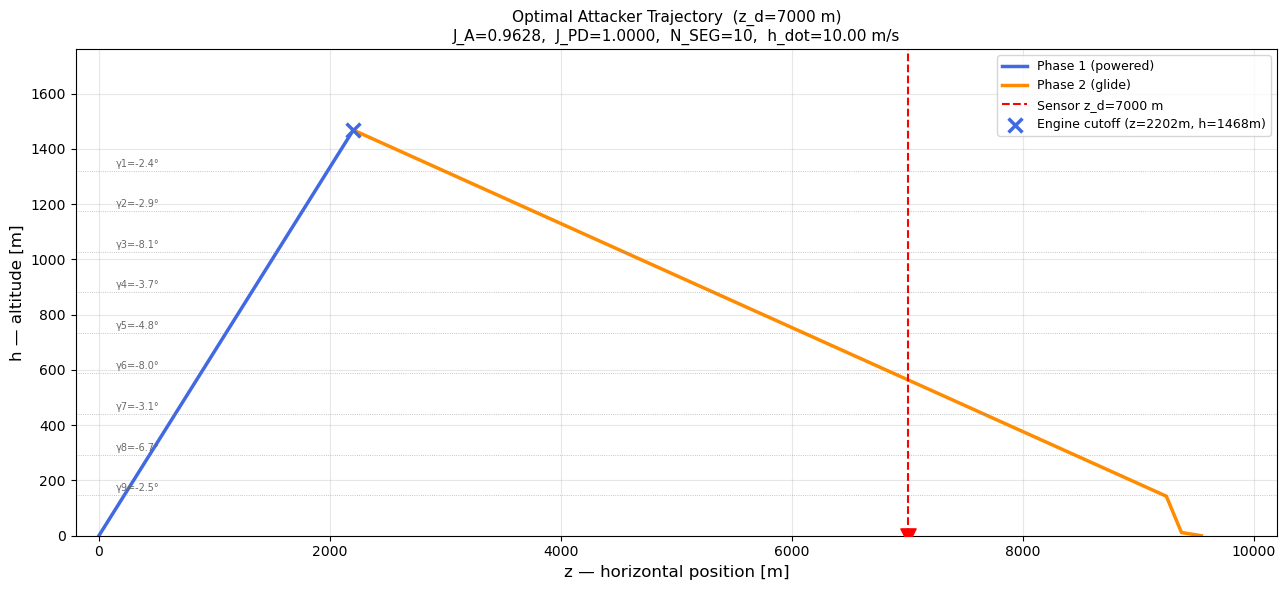

Plot 1 saved.


In [9]:
traj    = result['traj']
jpd_run = result['jpd_run']
gammas  = result['gammas']

ph1 = traj['phase'] == 1
ph2 = traj['phase'] == 2
cutoff_t = traj['t'][np.argmax(ph2)]
h_sw     = traj['h_sw']
z_sw     = traj['z_sw']
seg_bounds = np.linspace(h_sw, 0.0, N_SEG + 1)


# ── Plot 1: Trajectory ────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(traj['z'][ph1], traj['h'][ph1],
         color='royalblue', linewidth=2.5, label='Phase 1 (powered)')
ax1.plot(traj['z'][ph2], traj['h'][ph2], '-', color='darkorange', linewidth=2.5, label='Phase 2 (glide)')

# Segment boundary lines
for i, h_b in enumerate(seg_bounds[1:-1]):
    ax1.axhline(h_b, color='gray', linewidth=0.6, linestyle=':', alpha=0.6)
    ax1.text(Z_START + 150, h_b + h_sw*0.01,
             f'γ{i+1}={np.degrees(gammas[i]):.1f}°',
             fontsize=7, color='dimgray')

# Sensor
ax1.axvline(Z_D, color='red', linewidth=1.5, linestyle='--',
            label=f'Sensor z_d={Z_D:.0f} m')
ax1.scatter([Z_D], [0], color='red', s=120, zorder=6, marker='v')

# Engine cutoff
ax1.scatter([z_sw], [h_sw], color='royalblue', s=100, zorder=6,
            marker='x', linewidths=2.5,
            label=f'Engine cutoff (z={z_sw:.0f}m, h={h_sw:.0f}m)')

ax1.set_xlabel('z — horizontal position [m]', fontsize=12)
ax1.set_ylabel('h — altitude [m]', fontsize=12)
ax1.set_title(
    f'Optimal Attacker Trajectory  (z_d={Z_D:.0f} m)\n'
    f'J_A={result["J_A"]:.4f},  J_PD={result["J_PD"]:.4f},  '
    f'N_SEG={N_SEG},  h_dot={result["h_dot"]:.2f} m/s',
    fontsize=11
)
ax1.set_xlim([Z_START - 200, Z_GOAL + 200])
ax1.set_ylim([0, max(traj['h']) * 1.2])
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 1 saved.')

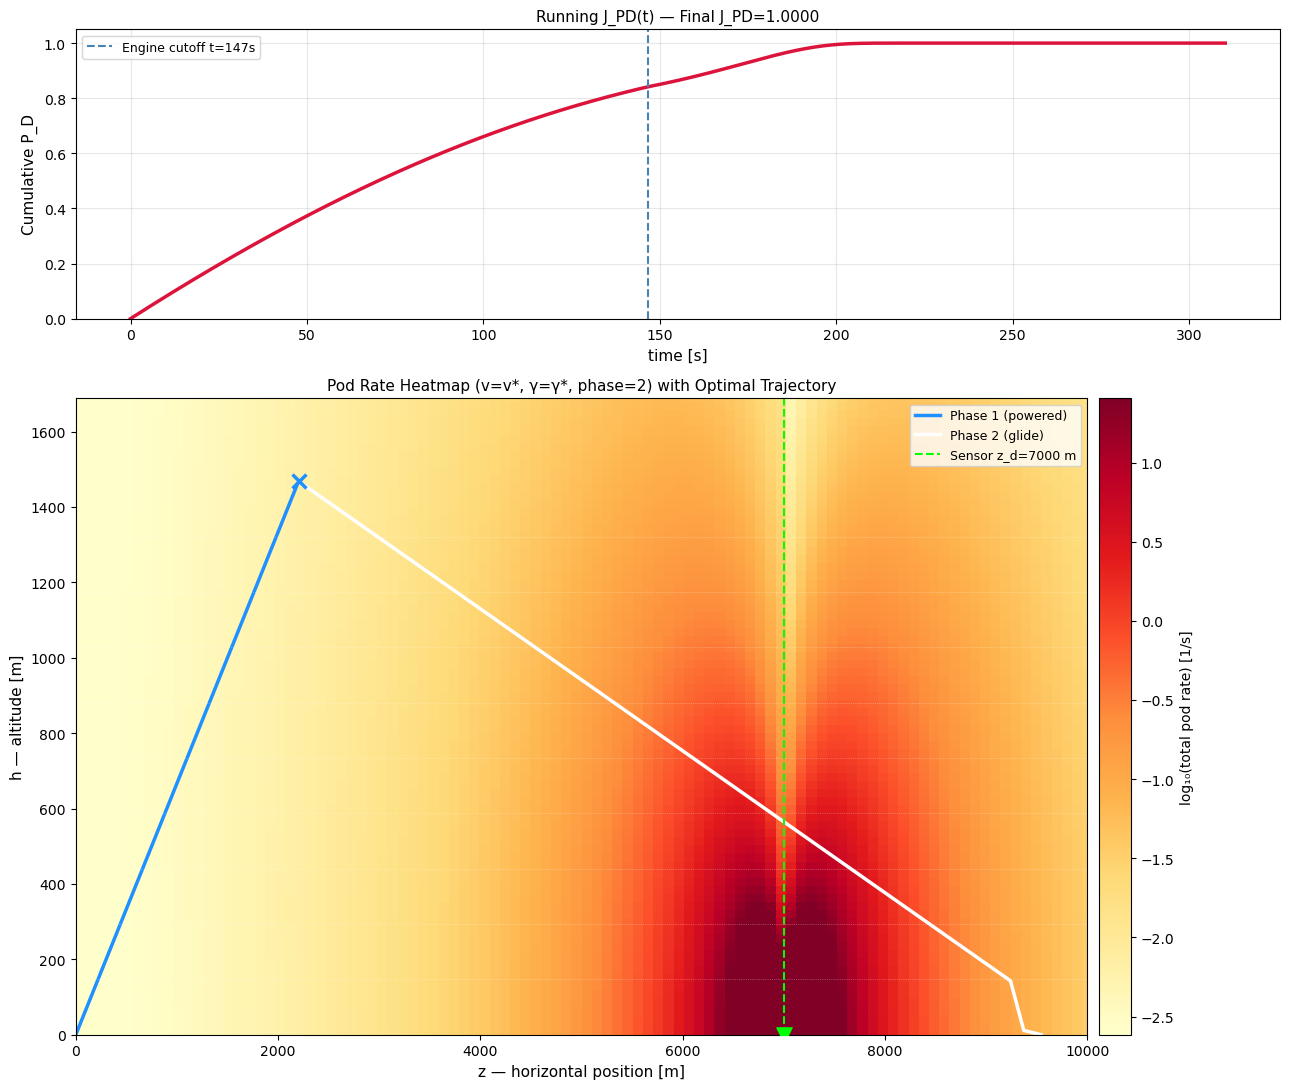

Plot 2 saved.


In [10]:
# ── Plot 2: Cumulative P_D + Heatmap ─────────────────────────────────────────

# Build heatmap grid
n_z, n_h = 100, 80
z_grid   = np.linspace(Z_START, Z_GOAL, n_z)
h_grid   = np.linspace(0, max(traj['h']) * 1.15, n_h)
ZZ, HH   = np.meshgrid(z_grid, h_grid)

v_map    = glide_speed(GAMMA_STAR)
rate_map = np.zeros((n_h, n_z))
for i in range(n_h):
    for j in range(n_z):
        rate_map[i, j] = lam_total(ZZ[i,j], HH[i,j], v_map, GAMMA_STAR, phase=2)

rate_map_log = np.log10(np.maximum(rate_map, 1e-12))

fig2, axes = plt.subplots(2, 1, figsize=(13, 11),
                           gridspec_kw={'height_ratios': [1, 2.2]})

# Top: running J_PD
axes[0].plot(traj['t'], jpd_run, color='crimson', linewidth=2.5)
axes[0].axvline(cutoff_t, color='steelblue', linestyle='--',
                linewidth=1.5, label=f'Engine cutoff t={cutoff_t:.0f}s')
axes[0].set_xlabel('time [s]', fontsize=11)
axes[0].set_ylabel('Cumulative P_D', fontsize=11)
axes[0].set_title(f'Running J_PD(t) — Final J_PD={result["J_PD"]:.4f}', fontsize=11)
axes[0].set_ylim([0, 1.05])
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom: heatmap + trajectory
im = axes[1].pcolormesh(ZZ, HH, rate_map_log, cmap='YlOrRd', shading='auto',
                         vmin=np.percentile(rate_map_log, 5),
                         vmax=np.percentile(rate_map_log, 98))
cbar = fig2.colorbar(im, ax=axes[1], pad=0.01)
cbar.set_label('log₁₀(total pod rate) [1/s]', fontsize=10)

axes[1].plot(traj['z'][ph1], traj['h'][ph1],
             color='dodgerblue', linewidth=2.5, label='Phase 1 (powered)')
axes[1].plot(traj['z'][ph2], traj['h'][ph2],
             color='white', linewidth=2.5, label='Phase 2 (glide)')

for h_b in seg_bounds[1:-1]:
    axes[1].axhline(h_b, color='white', linewidth=0.5, linestyle=':', alpha=0.5)

axes[1].axvline(Z_D, color='lime', linewidth=1.5, linestyle='--',
                label=f'Sensor z_d={Z_D:.0f} m')
axes[1].scatter([Z_D], [0], color='lime', s=120, zorder=6, marker='v')
axes[1].scatter([z_sw], [h_sw], color='dodgerblue', s=100, zorder=6,
                marker='x', linewidths=2.5)

axes[1].set_xlabel('z — horizontal position [m]', fontsize=11)
axes[1].set_ylabel('h — altitude [m]', fontsize=11)
axes[1].set_title(
    f'Pod Rate Heatmap (v=v*, γ=γ*, phase=2) with Optimal Trajectory',
    fontsize=11
)
axes[1].set_xlim([Z_START, Z_GOAL])
axes[1].set_ylim([0, max(traj['h']) * 1.15])
axes[1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('plot2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 2 saved.')

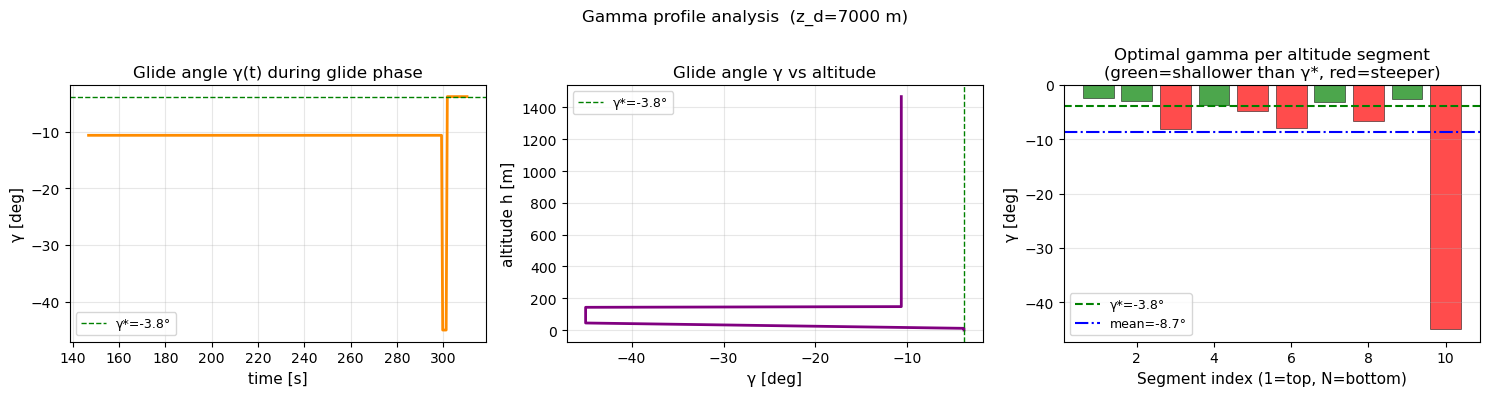

In [11]:
# ── Plot 3: Gamma profile over time and altitude ──────────────────────────────
fig3, axes = plt.subplots(1, 3, figsize=(15, 4))
fig3.suptitle(f'Gamma profile analysis  (z_d={Z_D:.0f} m)', fontsize=12)

traj    = result['traj']
gammas  = result['gammas']
ph2     = traj['phase'] == 2
cutoff_t = traj['t'][np.argmax(ph2)]

# Panel 1: gamma vs time
axes[0].plot(traj['t'][ph2], np.degrees(traj['gamma'][ph2]),
             color='darkorange', linewidth=2)
axes[0].axhline(np.degrees(GAMMA_STAR), color='green', linestyle='--',
                linewidth=1, label=f'γ*={np.degrees(GAMMA_STAR):.1f}°')
axes[0].set_xlabel('time [s]', fontsize=11)
axes[0].set_ylabel('γ [deg]', fontsize=11)
axes[0].set_title('Glide angle γ(t) during glide phase')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: gamma vs altitude
axes[1].plot(np.degrees(traj['gamma'][ph2]), traj['h'][ph2],
             color='purple', linewidth=2)
axes[1].axvline(np.degrees(GAMMA_STAR), color='green', linestyle='--',
                linewidth=1, label=f'γ*={np.degrees(GAMMA_STAR):.1f}°')
axes[1].set_xlabel('γ [deg]', fontsize=11)
axes[1].set_ylabel('altitude h [m]', fontsize=11)
axes[1].set_title('Glide angle γ vs altitude')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Panel 3: segment gammas as bar chart
seg_indices = np.arange(1, N_SEG + 1)
colors = ['green' if g > GAMMA_STAR else 'red'
          for g in gammas]
axes[2].bar(seg_indices, np.degrees(gammas), color=colors, alpha=0.7,
            edgecolor='black', linewidth=0.5)
axes[2].axhline(np.degrees(GAMMA_STAR), color='green', linestyle='--',
                linewidth=1.5, label=f'γ*={np.degrees(GAMMA_STAR):.1f}°')
axes[2].axhline(np.degrees(np.mean(gammas)), color='blue', linestyle='-.',
                linewidth=1.5, label=f'mean={np.degrees(np.mean(gammas)):.1f}°')
axes[2].set_xlabel('Segment index (1=top, N=bottom)', fontsize=11)
axes[2].set_ylabel('γ [deg]', fontsize=11)
axes[2].set_title('Optimal gamma per altitude segment\n'
                   '(green=shallower than γ*, red=steeper)')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plot3_gamma_profile.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 — Summary

In [12]:
print('=' * 55)
print('RESULTS SUMMARY')
print('=' * 55)
print(f'Scenario:')
print(f'  Corridor: z=[{Z_START:.0f}, {Z_GOAL:.0f}] m')
print(f'  Sensor:   z_d={Z_D:.0f} m')
print(f'  Segments: N={N_SEG}')
print(f'\nOptimal attacker trajectory:')
print(f'  h_dot  = {result["h_dot"]:.3f} m/s')
print(f'  h_sw   = {result["h_sw"]:.1f} m')
print(f'  z_sw   = {result["z_sw"]:.1f} m  (sensor at z_d={Z_D:.0f})')
print(f'  gammas = {np.degrees(result["gammas"]).round(2)} deg')
print(f'\nCosts:')
print(f'  J_PD   = {result["J_PD"]:.4f}')
print(f'  T_norm = {result["T_norm"]:.4f}')
print(f'  J_A    = {result["J_A"]:.4f}')
print(f'\nGamma variation:')
print(f'  std dev = {np.degrees(result["gammas"].std()):.4f} deg')
g_std = result['gammas'].std()
if g_std > np.radians(2.0):
    print('  ✓ Significant variation — three-way contradiction active')
elif g_std > np.radians(0.5):
    print('  ~ Moderate variation — contradiction partially active')
else:
    print('  ✗ Near-constant — adjust TARGET_PER_SENSOR or Z_D')
print('=' * 55)

RESULTS SUMMARY
Scenario:
  Corridor: z=[0, 10000] m
  Sensor:   z_d=7000 m
  Segments: N=10

Optimal attacker trajectory:
  h_dot  = 10.000 m/s
  h_sw   = 1468.0 m
  z_sw   = 2202.1 m  (sensor at z_d=7000)
  gammas = [ -2.43  -2.91  -8.12  -3.69  -4.76  -7.99  -3.08  -6.67  -2.52 -45.  ] deg

Costs:
  J_PD   = 1.0000
  T_norm = 0.6282
  J_A    = 0.9628

Gamma variation:
  std dev = 12.2713 deg
  ✓ Significant variation — three-way contradiction active
